<b>Group Number:</b>
<br><b>Name Group Member 1:</b>
<br><b>u-Kürzel Group Member 1:</b>
<br><b>Name Group Member 2:</b>
<br><b>u-Kürzel Group Member 2:</b>

# Unit 5: Model Evaluation Concepts & Metrics

## Introduction

In the previous units, we prepared the Bank Marketing dataset through cleaning, feature engineering, and appropriate splitting into training and testing sets (`X_train`, `X_test`, `y_train`, `y_test`). Now, we arrive at the crucial stage of **model evaluation**.

Simply training a model is not enough. We need robust methods and meaningful metrics to:
1.  Understand fundamental evaluation concepts like overfitting, underfitting, and the bias-variance trade-off.
2.  Quantify how well our models perform on unseen data.
3.  Compare different algorithms or model configurations fairly.
4.  Select the best model for our specific problem and goals, considering the context (e.g., the cost of different types of errors in bank marketing).

This unit covers:
*   Theoretical concepts: Overfitting, Underfitting, Bias-Variance Trade-off, No Free Lunch Theorem.
*   Core classification metrics: Confusion Matrix, Accuracy, Precision, Recall, F1-Score.
*   Advanced classification metrics: ROC Curve, AUC, Precision-Recall Curve, Average Precision.
*   Comparing multiple models using Cross-Validation on the training set.
*   Evaluating final models on the held-out test set.
*   Discussing model selection strategies.

In [10]:
# Import necessary libraries
import numpy as np
import fireducks.pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from typing import List, Dict, Any

# --- Core Evaluation Concepts Imports ---
from ipywidgets import interact, fixed
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error

# --- Classification Metrics Imports ---
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    average_precision_score,
)

# --- Model Comparison Imports ---
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score, StratifiedKFold

# Configure visualisation 
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
pd.set_option("display.precision", 4)

## 5.1 Loading Saved Data Splits

First, let's load the stratified training and testing data arrays (`X_train`, `X_test`, `y_train`, `y_test`) that we created and saved at the end of Unit 4. Using these saved files ensures consistency in our evaluation process.

In [11]:
# --- Load Saved Data Splits ---
X_train, X_test, y_train, y_test = None, None, None, None
data_loaded = False
data_dir = "data"
xtrain_load_path = os.path.join(data_dir, "bank_X_train_strat.npy")
xtest_load_path = os.path.join(data_dir, "bank_X_test_strat.npy")
ytrain_load_path = os.path.join(data_dir, "bank_y_train_strat.npy")
ytest_load_path = os.path.join(data_dir, "bank_y_test_strat.npy")

X_train = np.load(xtrain_load_path, allow_pickle=True)
X_test = np.load(xtest_load_path, allow_pickle=True)
y_train = np.load(ytrain_load_path, allow_pickle=True)
y_test = np.load(ytest_load_path, allow_pickle=True)
print("--- Loaded Saved Data Splits for Unit 4 ---")

--- Loaded Saved Data Splits for Unit 4 ---


## 5.2 Evaluation Concepts Review

Before calculating metrics, let's briefly review the key theoretical concepts.


### 5.2.1 Overfitting and Underfitting

This is a core challenge in supervised learning. We aim for a model that learns the true underlying relationship between features and the target, but avoids two pitfalls:

*   **Underfitting:** The model is too simplistic (e.g., using a straight line for curved data). It fails to capture the essential patterns present in the data. Consequently, it performs poorly not only on unseen test data but also on the data it was trained on. This indicates **high bias**.
*   **Overfitting:** The model is overly complex relative to the amount and complexity of the data (e.g., a very high-degree polynomial fitting noisy points). It learns the training data *too* well, essentially memorising specific examples, including random noise. While it achieves very low error on the training set, it fails to **generalise** to new data, resulting in poor performance on the test set. This indicates **high variance**.
*   **Good Fit (Generalisation):** The ideal model strikes a balance. It's complex enough to capture the significant patterns but simple enough to avoid fitting the noise. Such a model generalises well, performing adequately on both training and unseen test data.

In [12]:
# --- Overfitting/Underfitting Demo ---
np.random.seed(42)
n_samples_synth = 100
X_synth = np.sort(np.random.rand(n_samples_synth))
y_synth_true = np.sin(2 * np.pi * X_synth)  # True underlying function
y_synth = y_synth_true + np.random.normal(0, 0.3, size=n_samples_synth)  # Noise added
X_synth = X_synth.reshape(-1, 1)  # Reshape for sklearn
X_train_synth, X_test_synth, y_train_synth, y_test_synth = train_test_split(
    X_synth, y_synth, test_size=0.3, random_state=42
)


# Function to fit polynomial and plot
def plot_poly_fit(
    degree=1,
    X_train=X_train_synth,
    y_train=y_train_synth,
    X_test=X_test_synth,
    y_test=y_test_synth,
    y_true_func=y_synth_true,
    X_full_range=X_synth,
):
    model = Pipeline(
        [
            ("poly", PolynomialFeatures(degree=degree, include_bias=False)),
            ("linear", LinearRegression()),
        ]
    )
    model.fit(X_train, y_train)
    X_plot = np.linspace(0, 1, 100).reshape(-1, 1)
    y_plot = model.predict(X_plot)
    train_error = mean_squared_error(y_train, model.predict(X_train))
    test_error = mean_squared_error(y_test, model.predict(X_test))
    y_true_plot = np.sin(2 * np.pi * X_plot.ravel())

    plt.figure(figsize=(10, 6))
    plt.scatter(X_train, y_train, color="blue", s=30, alpha=0.7, label="Training data")
    plt.scatter(X_test, y_test, color="green", s=30, alpha=0.7, label="Testing data")
    plt.plot(
        X_plot,
        y_true_plot,
        color="gray",
        linestyle="--",
        label="True function (sin wave)",
    )
    plt.plot(
        X_plot, y_plot, color="red", linewidth=2, label=f"Polynomial (degree={degree})"
    )
    plt.title(
        f"Degree {degree} Polynomial Fit\nTrain MSE: {train_error:.3f}, Test MSE: {test_error:.3f}"
    )
    plt.xlabel("X")
    plt.ylabel("y")
    plt.ylim(-1.5, 1.5)
    plt.legend(loc="upper right")
    plt.grid(True, linestyle="--", alpha=0.7)
    plt.show()

<div class="alert alert-block alert-info">
<ul>
    <li> Run the code cell below to activate the interactive demo.</li>
    <li> Adjust the 'degree' slider.</li>
</ul>
</div>

In [13]:
# --- Run the interactive demo ---
print("Interactive Polynomial Regression Demo:")
interact(
    plot_poly_fit,
    degree=(1, 15, 1),
    X_train=fixed(X_train_synth),
    y_train=fixed(y_train_synth),
    X_test=fixed(X_test_synth),
    y_test=fixed(y_test_synth),
    y_true_func=fixed(y_synth_true),
    X_full_range=fixed(X_synth),
);

Interactive Polynomial Regression Demo:


interactive(children=(IntSlider(value=1, description='degree', max=15, min=1), Output()), _dom_classes=('widge…

<div class="alert alert-block alert-success">
<b>Question 5.1: Observe Overfitting/Underfitting (1.5 pts)</b>

<ul>
    <li> Observe how the fitted curve (red line) changes relative to the training data (blue), test data (green), and true function (gray).</li>
    <li> Pay attention to how the Train MSE and Test MSE values change with the degree.</li>
    <li> Describe what happens at <b>low degrees</b>, <b>intermediate degrees</b>, and <b>high degrees</b> in terms of fit and errors.</li>
</ul>
</div>



<div class="alert alert-block alert-success">
<b>Your Answer:</b>
<ul>
    <li></li>
    <li></li>
    <li></li>
</ul>
</div>

### 5.2.2 Bias-Variance Tradeoff

* **Bias (systematic error)** – Mistakes that arise because a model is **too simple** to capture the true relationship. High bias ⇒ *underfitting*: predictions are consistently off‑target in the same direction.  
* **Variance (estimation error)** – Extra error caused by a model being **too sensitive** to random fluctuations in the training set. High variance ⇒ *overfitting*: predictions jump around when the training data change.  
* **Irreducible error (noise, $\sigma^{2}$)** – The part of the error that **no model can remove**; it comes from measurement noise, unobserved variables, or inherent randomness in the process that generated the data.  
* **The trade‑off** – As we increase model complexity, **bias decreases** but **variance increases**.  

The expected squared prediction error decomposes into  

$$
\text{Total error} \;=\; (\text{Bias})^{2} \;+\; \text{Variance} \;+\; \sigma^{2}.
$$  

The *sweet spot* (labelled **Optimal Complexity** in the plot) is where this sum is smallest—choosing a model there gives the best chance of strong performance on unseen data.


Visualizing the Bias-Variance Tradeoff Concept:


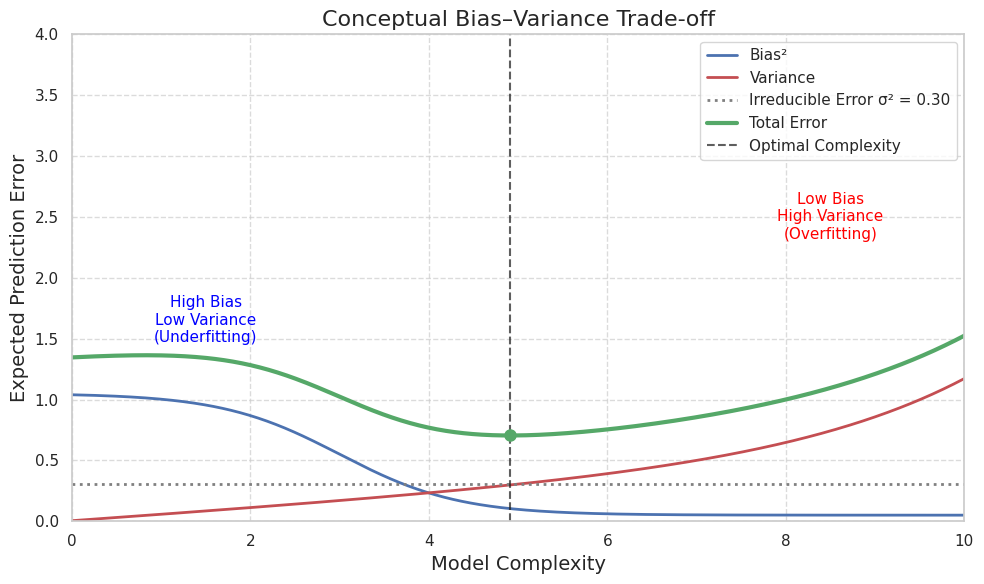

In [5]:
# --- Bias–Variance Trade‑off Plot (mathematically grounded) ------------------
print("Visualizing the Bias-Variance Tradeoff Concept:")
plt.figure(figsize=(10, 6))

x_complexity = np.linspace(0, 10, 500)  # Plot from 0 to 10 with 500 points

# ---------------------------------------------------------------------------
# 2. Define the three error components
#    • Bias²  – decays as the model becomes more flexible
#    • Variance – grows as the model becomes more flexible
#    • Irreducible error σ² – set by the data‑generating process
# ---------------------------------------------------------------------------

# Bias²: a smooth, monotonically decreasing curve
bias_squared = 1 / (1 + np.exp(1.5 * (x_complexity - 3))) + 0.05

# Variance: a curve that increases rapidly at high complexity
variance = 0.15 * np.exp(0.5 * (x_complexity - 7)) + 0.05 * x_complexity

# Irreducible error σ² (noise standard‑deviation)²:
noise_std = 0.55  # ← tweak this to see the effect
sigma_squared = noise_std**2
irreducible_error = np.full_like(x_complexity, sigma_squared)

# Total expected squared prediction error
total_error = bias_squared + variance + irreducible_error

plt.plot(x_complexity, bias_squared, "b-", linewidth=2, label="Bias²")
plt.plot(x_complexity, variance, "r-", linewidth=2, label="Variance")
plt.plot(
    x_complexity,
    irreducible_error,
    "gray",
    linestyle=":",
    linewidth=2,
    label=f"Irreducible Error σ² = {sigma_squared:.2f}",
)
plt.plot(x_complexity, total_error, "g-", linewidth=3, label="Total Error")

# Mark the minimum of the total error
min_error_idx = np.argmin(total_error)
min_error_x = x_complexity[min_error_idx]
min_error_y = total_error[min_error_idx]
plt.axvline(
    min_error_x, color="k", linestyle="--", alpha=0.7, label="Optimal Complexity"
)
plt.plot(min_error_x, min_error_y, "go", markersize=8)

plt.text(
    1.5,
    1.65,
    "High Bias\nLow Variance\n(Underfitting)",
    fontsize=11,
    ha="center",
    va="center",
    color="blue",
)
plt.text(
    8.5,
    2.5,
    "Low Bias\nHigh Variance\n(Overfitting)",
    fontsize=11,
    ha="center",
    va="center",
    color="red",
)

plt.xlabel("Model Complexity", fontsize=14)
plt.ylabel("Expected Prediction Error", fontsize=14)
plt.title("Conceptual Bias–Variance Trade‑off", fontsize=16)
plt.legend(fontsize=11)
plt.grid(True, linestyle="--", alpha=0.7)
plt.ylim(0, 4)
plt.xlim(0, 10)
plt.tight_layout()
plt.show()

### 5.2.3 "No Free Lunch" (NFL) Theorem

This theorem states that **no single machine learning algorithm is universally best** across all possible problems. An algorithm performing well on one type of data may perform poorly on another.

**Implications:**
*   We must experiment with multiple algorithms suitable for our problem type.
*   Performance must be evaluated empirically on our specific dataset (using techniques like CV and test sets).
*   Domain knowledge can help guide algorithm selection, but doesn't guarantee superiority.

Visualising the 'No Free Lunch' Theorem Concept:


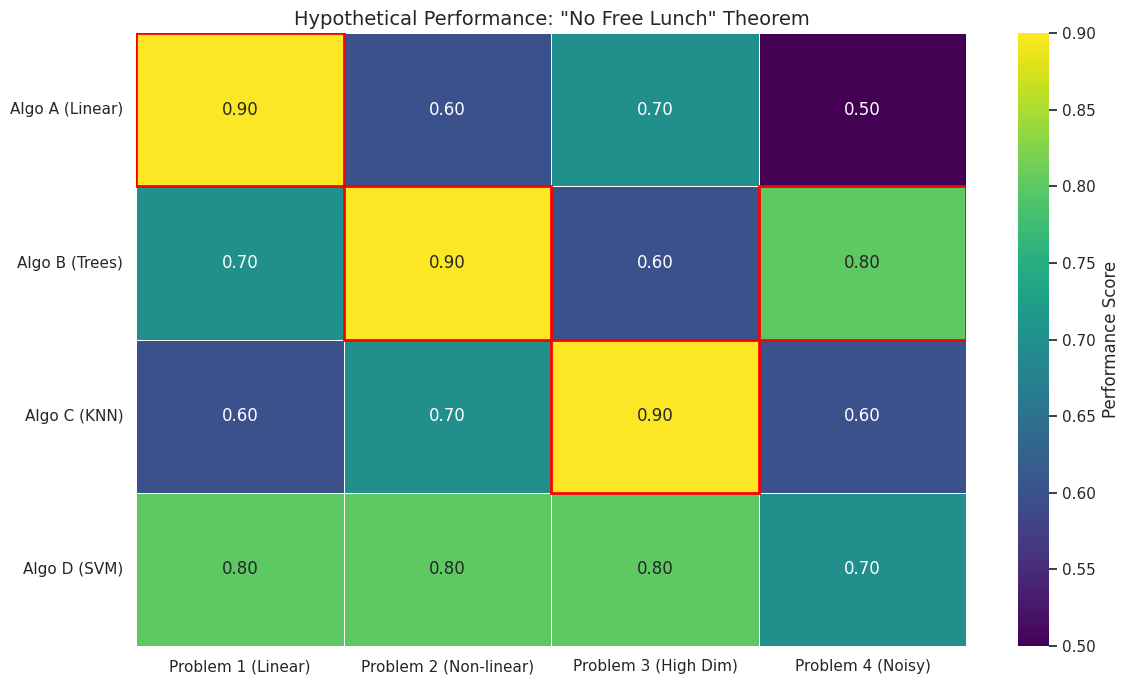

In [6]:
# --- "No Free Lunch" Plot  ---
print("Visualising the 'No Free Lunch' Theorem Concept:")
plt.figure(figsize=(12, 7))
algorithms = ["Algo A (Linear)", "Algo B (Trees)", "Algo C (KNN)", "Algo D (SVM)"]
problems = [
    "Problem 1 (Linear)",
    "Problem 2 (Non-linear)",
    "Problem 3 (High Dim)",
    "Problem 4 (Noisy)",
]
performance = np.array(
    [
        [0.9, 0.6, 0.7, 0.5],
        [0.7, 0.9, 0.6, 0.8],
        [0.6, 0.7, 0.9, 0.6],
        [0.8, 0.8, 0.8, 0.7],
    ]
)
sns.heatmap(
    performance,
    annot=True,
    cmap="viridis",
    fmt=".2f",
    linewidths=0.5,
    cbar_kws={"label": "Performance Score"},
)
plt.xticks(np.arange(len(problems)) + 0.5, problems, rotation=0, fontsize=11)
plt.yticks(np.arange(len(algorithms)) + 0.5, algorithms, rotation=0, fontsize=11)
for j in range(len(problems)):
    plt.gca().add_patch(
        plt.Rectangle(
            (j, np.argmax(performance[:, j])), 1, 1, fill=False, edgecolor="red", lw=2
        )
    )
plt.title('Hypothetical Performance: "No Free Lunch" Theorem', fontsize=14)
plt.tight_layout()
plt.show()

## 5.3 Baseline Model and Core Classification Metrics

Let's train a simple baseline model, **Logistic Regression**, on our Bank Marketing training data (`X_train`, `y_train`). We will then use its predictions on the test set (`X_test`) to calculate and understand the core classification metrics.

In [7]:
# --- Train a Baseline Logistic Regression Model ---
baseline_model = None
y_pred_baseline = None
y_proba_baseline = None

print("--- Training Baseline Logistic Regression Model ---")
baseline_model = LogisticRegression(solver="liblinear", random_state=42, max_iter=1000)

baseline_model.fit(X_train, y_train)
print("Baseline model trained successfully.")

y_pred_baseline = baseline_model.predict(X_test)
y_proba_baseline = baseline_model.predict_proba(X_test)[:, 1]
print("Predictions made on the test set.")

--- Training Baseline Logistic Regression Model ---
Baseline model trained successfully.
Predictions made on the test set.


### 5.3.1 Confusion Matrix

This table summarizes correct and incorrect predictions:
             Predicted Negative (0)  Predicted Positive (1)
             Actual Negative (0) TN FP (Type I Error)
             Actual Positive (1) FN (Type II Error) TP
*   **TN:** True Negative (Correctly predicted 'no')
*   **FP:** False Positive (Incorrectly predicted 'yes')
*   **FN:** False Negative (Incorrectly predicted 'no')
*   **TP:** True Positive (Correctly predicted 'yes')

<div class="alert alert-block alert-success">
<b>Task 5.1: Calculate and Visualize Confusion Matrix (1 pt)</b>

<ul>
    <li> Use <code>sklearn.metrics.confusion_matrix</code> to calculate the confusion matrix for the baseline model's predictions (<i>y_test</i>, <i>y_pred_baseline</i>).</li>
    <li> Use <code>sklearn.metrics.ConfusionMatrixDisplay</code> to create a clear visualization of the matrix with appropriate labels (<i>No Subscription</i>, <i>Subscription</i>).</li>
</ul>
</div>

In [8]:
print("\n--- Confusion Matrix (Baseline Model) ---")

# Calculate confusion matrix
cm_baseline: np.array = None
### STUDENT CODE HERE (0.5 pt) 


### STUDENT CODE until HERE 
print("Confusion Matrix:\n", cm_baseline)

# Visualize confusion matrix, don't forget to make the plot look nice, via labels, or ...
### STUDENT CODE HERE (0.5 pt) 


### STUDENT CODE until HERE 


--- Confusion Matrix (Baseline Model) ---
Confusion Matrix:
 None


### 5.3.2 Accuracy, Precision, Recall, F1-Score

These metrics provide different perspectives on performance, derived from the confusion matrix:

*   **Accuracy:** Overall correctness = `(TP + TN) / Total`.
*   **Precision:** Of those predicted positive, how many actually were? = `TP / (TP + FP)`. High precision minimizes False Positives.
*   **Recall (Sensitivity):** Of all actual positives, how many were found? = `TP / (TP + FN)`. High recall minimizes False Negatives.
*   **F1-Score:** Harmonic mean of Precision and Recall = `2 * (Prec * Rec) / (Prec + Rec)`. Balances both metrics.

<div class="alert alert-block alert-success">
<b>Task 5.2: Calculate Core Classification Metrics (1.5 pts)</b>

<ul>
    <li> Calculate these metrics for the baseline model's predictions (<i>y_test</i>, <i>y_pred_baseline</i>).</li>
    <li> Print each calculated metric, clearly labeled.</li>
    <li> You can consider using <code>sklearn.metrics.classification_report</code> to get a comprehensive summary including metrics per class.</li>
</ul>
</div>

In [ ]:
print("\n--- Core Classification Metrics (Baseline Model) ---")

# Calculate metrics
accuracy_base: float = 0.0
precision_base: float = 0.0
recall_base: float = 0.0
f1_base: float = 0.0
### STUDENT CODE HERE (1 pt) 


### STUDENT CODE until HERE 

print(f"Accuracy:  {accuracy_base:.4f}")
print(f"Precision (for class 1 'yes'): {precision_base:.4f}")
print(f"Recall    (for class 1 'yes'): {recall_base:.4f}")
print(f"F1-Score  (for class 1 'yes'): {f1_base:.4f}")

# Generate and print classification report
print("\nClassification Report:")
### STUDENT CODE HERE (0.5 pt) 


### STUDENT CODE until HERE 

<div class="alert alert-block alert-success">
<b>Question 5.2: Interpreting Baseline Metrics (1.5 pts)</b>
<ol>
    <li> Look at the Accuracy. Given the class imbalance (~11-12% <i>yes</i>), is accuracy a reliable measure of performance here? Why or why not?</li>
    <li> Look at the Precision and Recall for the <i>Subscription (1)</i> class. What do these values tell you about the baseline model's ability to correctly identify subscribers versus its tendency to misclassify non-subscribers as subscribers (or vice-versa)?</li>
    <li> In the context of bank marketing, would you prioritize higher Precision or higher Recall for the <i>Subscription (1)</i> class? Justify your choice (consider the potential costs of False Positives vs. False Negatives).</li>
</ol>
</div>

<div class="alert alert-block alert-success">
<b>Your Answer:</b>
<ol>
    <li></li>
    <li></li>
    <li></li>
</ol>
</div>

## 5.4 Advanced Metrics: ROC/AUC and Precision-Recall Curves

These metrics evaluate performance across different probability thresholds, giving a more complete picture than metrics based on a single threshold (like the default 0.5 used for `predict`).

*   **ROC Curve (Receiver Operating Characteristic):** Plots True Positive Rate (Recall) vs. False Positive Rate (`FP / (FP + TN)`) at various thresholds.
    *   **AUC (Area Under ROC Curve):** Summarizes the ROC curve. 1 = perfect, 0.5 = random. Measures overall ability to discriminate between classes. Good for balanced datasets or when overall ranking is important.
*   **PR Curve (Precision-Recall):** Plots Precision vs. Recall at various thresholds.
    *   **AP (Average Precision):** Summarizes the PR curve. Higher is better. More informative than ROC/AUC for highly imbalanced datasets because it focuses on the minority (positive) class performance. The baseline is the proportion of positive samples.

<div class="alert alert-block alert-success">
<b>Task 5.3: Calculate and Plot ROC and PR Curves (2 pts)</b>

<ul>
    <li> Use the true test labels (<i>y_test</i>) and the predicted probabilities for the positive class (<i>y_proba_baseline</i>) from the baseline model.</li>
    <li> Calculate the ROC curve values (fpr, tpr) and the AUC score using the appropriate sklearn methods.</li>
    <li> Calculate the PR curve values (precision, recall) and the Average Precision score.</li>
    <li> Plot both the ROC curve (including AUC in the label and the diagonal random chance line) and the PR curve (including AP in the label and the baseline performance line).</li>
</ul>
</div>

In [ ]:
print("\n--- ROC/AUC and PR Curve/AP (Baseline Model) ---")
### Earlier we imported useful sklearn functions for this!
tpr: np.array = None
fpr: np.array = None
roc_thresholds: np.array = None

roc_auc: float = 0.0
precision_pr: np.array = None
recall_pr: np.array = None
pr_thresholds: np.array = None
average_precision: float = 0.0

### STUDENT CODE HERE (1 pt) 


### STUDENT CODE until HERE 

print(f"ROC AUC Score: {roc_auc:.4f}")
print(f"Average Precision Score (AP): {average_precision:.4f}")

# --- Plotting ---
plt.figure(figsize=(14, 6))

### STUDENT CODE HERE (1 pt) 


### STUDENT CODE until HERE 

plt.tight_layout()
plt.show()

## 5.5 Comparing Multiple Models using Cross-Validation

The "No Free Lunch" theorem tells us we should try multiple algorithms. We can use k-fold cross-validation (on the *training set*) to get a more robust estimate of how different algorithms might perform before selecting one for final testing. We'll use `StratifiedKFold` because our data is imbalanced.

Let's compare:
*   Logistic Regression (LR)
*   K-Nearest Neighbors (KNN)
*   Decision Tree (CART)
*   Gaussian Naive Bayes (NB)
*   Support Vector Machine (SVM) with a linear kernel
*   (Optionally) Linear Discriminant Analysis (LDA)

<br>
We'll cover these later throughout the course in detail.

<div class="alert alert-block alert-success">
<b>Task 5.4: Compare Models with Cross-Validation (3 pts)</b>

<ul>
    <li> Define a dictionary containing instances of the models listed above (use default parameters or simple ones like <code>n_neighbors=5</code> for KNN, <code>random_state=RANDOM_SEED</code> where applicable).</li>
    <li> Loop through each model in your dictionary:
        <ul>
            <li>Use <code>sklearn.model_selection.cross_val_score</code> to perform stratified 10-fold CV on the <b>training data</b> (<i>X_train</i>, <i>y_train</i>).</li>
            <li>Choose a scoring metric (e.g., <i>roc_auc</i>, <i>f1</i>, <i>accuracy</i>). Given the imbalance, <i>roc_auc</i> or <i>f1</i> are often better than <i>accuracy</i>. Let's use <i>roc_auc</i>.</li>
            <li>Store the results (array of scores for each fold).</li>
        </ul>
    </li>
    <li> Calculate and print the mean and standard deviation of the chosen scoring metric for each model based on the CV results.</li>
    <li> Create a box plot comparing the distribution of CV scores for each algorithm.</li>
</ul>
</div>

In [ ]:
print(
    "\n--- Comparing Models using 10-Fold Stratified Cross-Validation (on Training Data) ---"
)
RANDOM_SEED: int = 42
models: Dict[str, Any] = {
    "LR": None,  # Logistic Regression
    "KNN": None,  # K-Nearest Neighbors
    "CART": None,  # Classification and Regression Trees
    "NB": None,  # Naive Bayes
    "SVM": None,  # Support Vector Machine
}
results_cv: Dict[str, np.ndarray] = {}
mean_scores: Dict[str, float] = {}
std_scores: Dict[str, float] = {}

### STUDENT CODE HERE (1 pt)


### STUDENT CODE until HERE

# Define CV strategy and scoring
kfold = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_SEED)
scoring_metric = "roc_auc"  # Comparison metric for classification. You can change this to "accuracy" or others if desired

print(f"\nPerforming 10-fold CV using scoring: '{scoring_metric}'")

### STUDENT CODE HERE (1 pt)


### STUDENT CODE until HERE

# --- Visualize CV Results ---
if results_cv:
    print("\nVisualizing Cross-Validation Results...")
    fig, ax = plt.subplots(figsize=(12, 7))

    plot_data = [scores for scores in results_cv.values() if len(scores) > 0]
    plot_labels = [name for name, scores in results_cv.items() if len(scores) > 0]

    if plot_data:
        ### STUDENT CODE HERE (1 pt)


        ### STUDENT CODE until HERE
        plt.show()
    else:
        print("No valid CV results to plot.")
else:
    print("No CV results were generated.")

## 5.6 Evaluating Multiple Models on the Test Set

Cross-validation helps us estimate generalization performance and compare models robustly. Now, we take the models (perhaps the best performers from CV, or all of them for comparison) and train them one last time on the **entire training set** (`X_train`, `y_train`). Then, we evaluate their final performance on the **held-out test set** (`X_test`, `y_test`) using multiple metrics.

<div class="alert alert-block alert-success">
<b>Task 5.5: Final Evaluation on Test Set (2.5 pts)</b>

<ul>
    <li> Iterate through the <i>models</i> dictionary defined previously.</li>
    <li> For each model:
        <ol>
            <li>Train the model on the <b>full</b> <i>X_train</i>, <i>y_train</i>.</li>
            <li>Make predictions (<i>y_pred</i>) on the <i>X_test</i> set.</li>
            <li>Generate and print the <i>classification_report</i> for this model on the test set (<i>y_test</i>, <i>y_pred</i>).</li>
            <li>Calculate the ROC AUC score on the test set and print it for each model as well with the report.</li>
        </ol>
    </li>
    <li> Compare the test set performance across models.</li>
</ul>
</div>

In [48]:
print("\n--- Evaluating Final Models on the Test Set ---")

test_results_reports: Dict[str, str] = {}
test_results_auc: Dict[str, float] = {}

### STUDENT CODE HERE (2.5 pts)


### STUDENT CODE until HERE

## 5.7 Model Selection Discussion

Based on the cross-validation results (providing robustness) and the final test set evaluation (providing a final unbiased estimate), we can now discuss which model(s) performed best for the Bank Marketing prediction task.

Considerations:
*   **Overall Performance:** Which models had higher average CV scores (e.g., ROC AUC)? Which performed well on the test set AUC?
*   **Performance on Minority Class:** Look at Precision, Recall, and F1-Score for the 'Subscription (1)' class in the test set classification reports. This is crucial due to the class imbalance.
*   **Business Goal Alignment:** Revisit the discussion from Question 5.2. If the goal is to maximize the capture of potential subscribers (prioritize Recall), which model did best? If the goal is to minimize contacting uninterested clients (prioritize Precision), which model excelled?
*   **Consistency:** Did the models that performed well in CV also perform well on the test set?
*   **Complexity & Interpretability:** Are some models (like Decision Trees or Logistic Regression) easier to understand or explain than others (like SVM)? This can be a factor in real-world deployment.

<div class="alert alert-block alert-success">
<b>Question 5.3: Model Selection Justification (1.5 pts)</b>
<ol>
    <li> Based on the CV results (e.g., mean ROC AUC) and the final test set evaluations (Classification Reports, Test AUC), which 1-2 algorithms seem most promising for this task?</li>
    <li> Justify your choice(s) by referring to specific metrics (e.g., F1-score or Recall for class 1, overall AUC) and explaining how they align with potential business goals for bank marketing (choose one goal, e.g., maximizing subscriber capture).</li>
    <li> Briefly mention any potential drawbacks or trade-offs associated with your chosen model(s).</li>
</ol>
</div>

<div class="alert alert-block alert-success">
<b>Your Answer:</b>
<ol>
    <li></li>
    <li></li>
    <li></li>
</ol>
</div>

## Unit 5 Summary & Deep Dive Topics

In this comprehensive unit, we covered the essential concepts and practical application of model evaluation in machine learning. We reviewed overfitting, underfitting, the bias-variance tradeoff, and the implications of the "No Free Lunch" theorem. Using the processed Bank Marketing data splits, we trained a baseline Logistic Regression model and calculated key classification metrics: Confusion Matrix, Accuracy, Precision, Recall, and F1-Score, emphasizing their interpretation in the context of imbalanced data. We explored advanced, threshold-independent metrics like ROC/AUC and PR Curve/AP. Finally, we compared multiple algorithms using robust cross-validation on the training set and performed a final evaluation on the held-out test set, culminating in a discussion on model selection based on performance and business context.

Mastering these evaluation techniques is crucial for building reliable and effective machine learning models.


### Deep Dive Topics

#### 1. Hyperparameter Tuning with Cross-Validation:

Most machine learning algorithms have **hyperparameters**: settings that are *not* learned from the data during training but are set beforehand. Examples include:
*   `C` (regularization strength) in Logistic Regression and SVM.
*   `n_neighbors` (number of neighbors) in KNN.
*   `max_depth`, `min_samples_split` in Decision Trees.
*   `kernel`, `gamma` in SVM.

The default values for these hyperparameters are often not optimal for a specific dataset. **Hyperparameter Tuning** (or Optimization) is the process of systematically searching for the combination of hyperparameter values that yields the best model performance.

**Why Cross-Validation is Crucial for Tuning:**
If you tune hyperparameters based on the performance on the final *test set*, you risk **overfitting the hyperparameters** to that specific test set. The chosen hyperparameters might work well for *that* test set but generalize poorly to new unseen data.

Instead, tuning should be performed using **cross-validation *only* on the training set**:
1.  Split the original data into training and test sets (as done in Unit 4). **Set the test set aside.**
2.  Define a range or distribution of hyperparameter values to explore (the "search space").
3.  For each combination of hyperparameters in the search space:
    *   Perform k-fold cross-validation (e.g., 5 or 10 folds) *within the training set*.
    *   Calculate the average performance metric (e.g., mean ROC AUC, mean F1-score) across the k folds for that hyperparameter combination.
4.  Select the hyperparameter combination that resulted in the best average cross-validation score.
5.  **Finally**, train a *new* model using these best hyperparameters on the **entire training set**.
6.  Evaluate this final model *once* on the **held-out test set** to get an unbiased estimate of its generalization performance.

**Common Tuning Methods:**
*   **Grid Search (`GridSearchCV`):** Exhaustively tries every possible combination of hyperparameter values specified in a grid. Can be computationally expensive if the grid is large.
*   **Random Search (`RandomizedSearchCV`):** Samples a fixed number of hyperparameter combinations randomly from specified distributions. Often more efficient than Grid Search, especially when some hyperparameters are more important than others, as it explores a wider range of values more quickly.

*   **Further Reading & Resources:**
    *   Scikit-learn User Guide: [Tuning the hyper-parameters of an estimator](https://scikit-learn.org/stable/modules/grid_search.html) (Covers GridSearchCV, RandomizedSearchCV, and concepts)
    *   Scikit-learn Documentation: [`GridSearchCV`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html), [`RandomizedSearchCV`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.RandomizedSearchCV.html)
    *   Towards Data Science Article: [Hyperparameter Tuning the Random Forest in Python](https://towardsdatascience.com/hyperparameter-tuning-the-random-forest-in-python-using-scikit-learn-28d2aa77dd74) (Example with practical code, concepts apply broadly)
    *   Machine Learning Mastery: [How to Tune Algorithm Parameters with Scikit-Learn](https://machinelearningmastery.com/how-to-tune-algorithm-parameters-with-scikit-learn/)
    *   Paper/Overview (More Advanced): [Algorithms for Hyper-Parameter Optimization (NIPS 2011)](https://papers.nips.cc/paper/2011/hash/86e8f7ab32cfd12577bc2619bc635690-Abstract.html) (Discusses Random Search vs Grid Search)

#### 2. Statistical Significance Testing for Model Comparison:

When comparing two models (e.g., Model A and Model B), we often look at their performance metrics on a test set or their average scores from cross-validation. Suppose Model A achieves an F1-score of 0.75 and Model B achieves 0.73. Is Model A truly better, or could this difference simply be due to random chance related to the specific data split or sample?

**Statistical Significance Testing** helps answer this question. It provides a framework to determine the probability (the *p-value*) that an observed difference in performance is purely due to random variation, assuming there's actually no real difference between the models (the "null hypothesis").

*   **Low p-value (e.g., < 0.05):** If the p-value is below a predefined significance level (alpha, commonly 0.05), we *reject the null hypothesis*. This suggests the observed difference is unlikely to be due to chance alone, providing evidence that one model is genuinely better than the other *on the data distribution represented by our sample*.
*   **High p-value (e.g., >= 0.05):** We *fail to reject the null hypothesis*. This doesn't prove the models are the same, but it means we don't have strong statistical evidence to conclude that the observed difference is real. The difference could plausibly be due to random sampling variation.

**Common Tests for Comparing Classifiers:**

*   **Paired Tests on Cross-Validation Scores:** If you have the scores from each fold of k-fold CV for two models, you can use a **paired statistical test** (like a paired t-test or Wilcoxon signed-rank test, depending on assumptions about the score distributions) to compare the *mean* scores. The pairing accounts for the fact that both models were evaluated on the same folds.
    *   *Check out:* `scipy.stats.ttest_rel` (paired t-test) or `scipy.stats.wilcoxon` (non-parametric alternative). Libraries like `statsmodels` also offer relevant tests. MLxtend (`mlxtend.evaluate.paired_ttest_kfold_cv`) provides convenience functions.
*   **McNemar's Test:** This test is specifically designed for comparing two classifiers based on their predictions on the *same test set*. It uses a 2x2 contingency table focusing on the disagreements between the two models (samples where one model was right and the other was wrong). It's particularly useful for paired binary classification results.
    *   *Check out:* `statsmodels.stats.contingency_tables.mcnemar` or `mlxtend.evaluate.mcnemar`.

**Why Use Statistical Tests?**
Relying solely on point estimates (like a single accuracy score or mean CV score) can be misleading. Statistical tests add rigor by quantifying the uncertainty around these estimates and helping us make more informed decisions about whether one model's apparent superiority is statistically meaningful or just noise.


*   **Further Reading & Resources:**
    *   Scikit-learn Example: [Statistical comparison of models using grid search cross-validation](https://scikit-learn.org/stable/auto_examples/model_selection/plot_grid_search_stats.html) (Demonstrates comparing models after tuning)
    *   Machine Learning Mastery: [Statistical Significance Tests for Comparing Machine Learning Algorithms](https://machinelearningmastery.com/statistical-significance-tests-for-comparing-machine-learning-algorithms/)
    *   Paper (Classic Reference): [Approximate Statistical Tests for Comparing Supervised Classification Learning Algorithms (Dietterich, 1997)](https://sci2s.ugr.es/keel/pdf/algorithm/articulo/dietterich1998.pdf) (Discusses limitations of simple t-tests and proposes alternatives like 5x2cv)
    *   KD nuggets: [Comparing Machine Learning Models: Statistical vs. Practical Significance](https://www.kdnuggets.com/2019/01/comparing-machine-learning-models-statistical-vs-practical-significance.html) (Discusses interpretation)